DESCRIPTION

In [1]:
import plotly.express as px
import pandas as pd


# --- 1. CONFIGURATION ET CHARGEMENT ---

# Chargement du dataset
df = pd.read_csv('Speed+Dating+Data.csv', encoding='ISO-8859-15')


# --- 2. STATISTIQUES DESCRIPTIVES ---
print("--- APERÇU DES DONNÉES ---")

# On regarde l'âge moyen et le taux de match global

print(f"Âge moyen des participants : {df['age'].mean():.2f} ans")
print(f"Taux de match global : {df['match'].mean()*100:.2f}%")

#  Calcul de l'âge moyen par genre
# gender 0 = Femme, gender 1 = Homme
ages_moyens = df.groupby('gender')['age'].mean()

print("Âge moyen des femmes :", round(ages_moyens[0], 2), "ans")
print("Âge moyen des hommes :", round(ages_moyens[1], 2), "ans")

# Répartition par genre

gender_counts = df['gender'].value_counts()
print(f"\nRépartition par genre (0=Femme, 1=Homme) :\n{gender_counts}")


--- APERÇU DES DONNÉES ---
Âge moyen des participants : 26.36 ans
Taux de match global : 16.47%
Âge moyen des femmes : 26.11 ans
Âge moyen des hommes : 26.61 ans

Répartition par genre (0=Femme, 1=Homme) :
gender
1    4194
0    4184
Name: count, dtype: int64


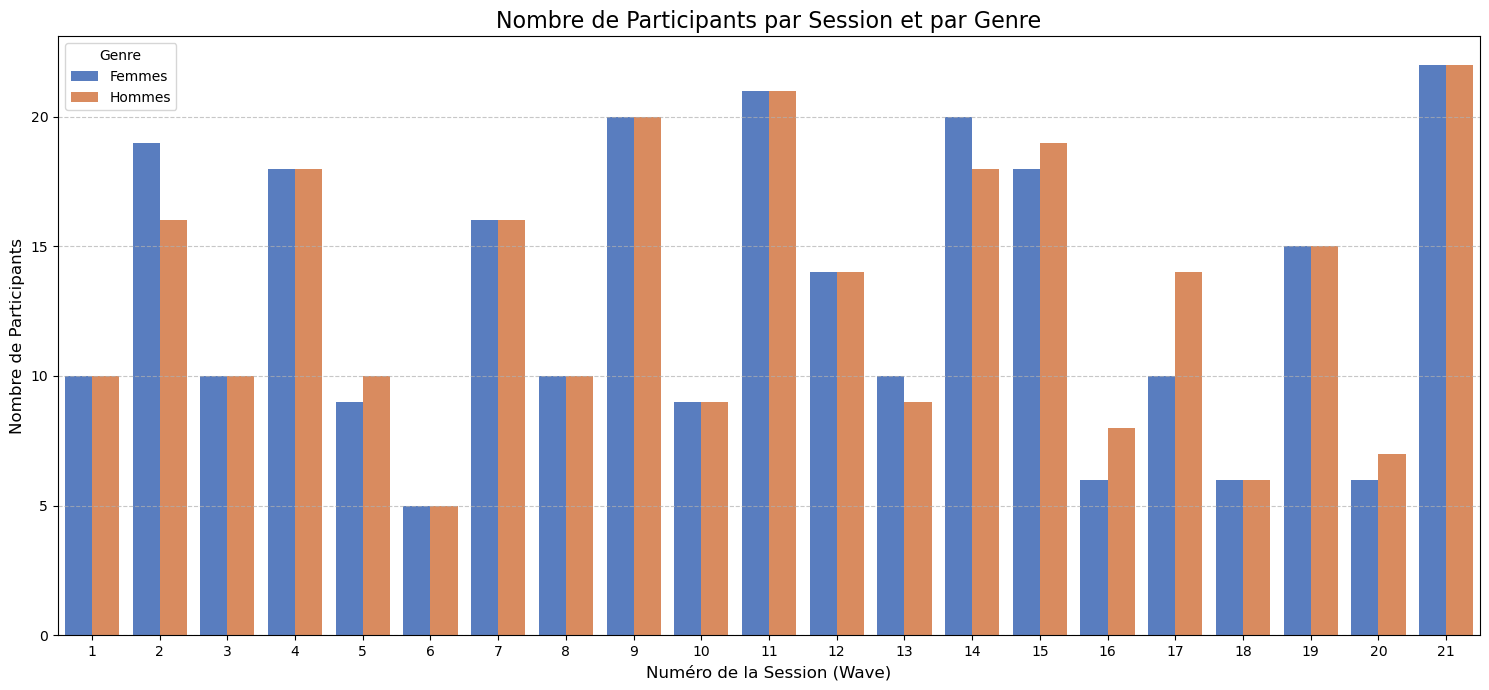

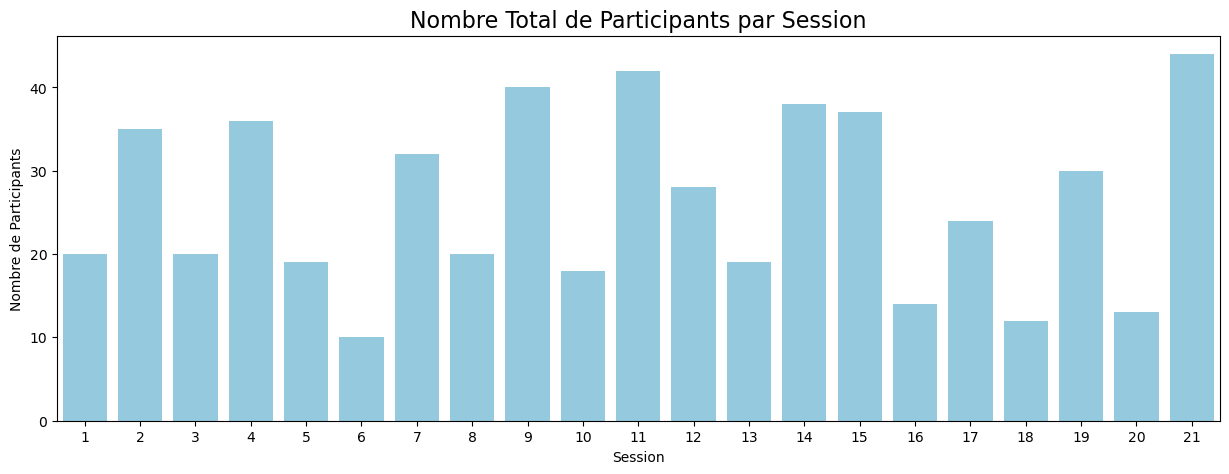

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Préparation des données pour le rapport
# On compte les identifiants uniques (iid) par session (wave) et par genre
participants = df.groupby(['wave', 'gender'])['iid'].nunique().reset_index()

# On renomme les colonnes pour plus de clarté
participants['gender'] = participants['gender'].map({0: 'Femmes', 1: 'Hommes'})
participants.columns = ['Session', 'Genre', 'Nombre de Participants']

# 3. Création du Barplot
plt.figure(figsize=(15, 7))

# Utilisation de Seaborn pour un barplot groupé
sns.barplot(data=participants, x='Session', y='Nombre de Participants', hue='Genre', palette='muted')

# Personnalisation du graphique
plt.title('Nombre de Participants par Session et par Genre', fontsize=16)
plt.xlabel('Numéro de la Session (Wave)', fontsize=12)
plt.ylabel('Nombre de Participants', fontsize=12)
plt.legend(title='Genre')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage du graphique
plt.tight_layout()
plt.show()

# total cumulé par session ---
total_per_wave = participants.groupby('Session')['Nombre de Participants'].sum().reset_index()

plt.figure(figsize=(15, 5))
sns.barplot(data=total_per_wave, x='Session', y='Nombre de Participants', color='skyblue')
plt.title('Nombre Total de Participants par Session', fontsize=16)
plt.show()

In [3]:
# --- 2. ANALYSE : CE QUE LES GENS DISENT VS CE QU'ILS FONT --
# -
# Les colonnes 'attr1_1' à 'shar1_1' indiquent les qualités que le participant dit chercher.
# Les colonnes 'attr' à 'shar' sont les notes réelles données au partenaire.

importance_cols = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
actual_rating_cols = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
labels = ['Attrait', 'Sincérité', 'Intelligence', 'Humour', 'Ambition', 'Partage']

# Calcul des préférences déclarées par genre
stated_pref = df.groupby('gender')[importance_cols].mean()
stated_pref.columns = labels

# Calcul de la corrélation réelle entre la note et la décision finale (dec)
#Filtrage : On ne garde que les hommes ou les femmes.
#Sélection : On prend les colonnes de notes (actual_rating_cols) et la colonne de décision (dec).
#.corr() : On calcule la matrice de corrélation (un score entre -1 et 1).
#['dec'] : On isole uniquement la relation avec la décision finale.

corr_f = df[df['gender'] == 0][actual_rating_cols + ['dec']].corr()['dec'][actual_rating_cols]
corr_m = df[df['gender'] == 1][actual_rating_cols + ['dec']].corr()['dec'][actual_rating_cols]

# Transformation des préférences déclarées en format long si positif les valeurs sont en corrélation ni négatif ou si = 0 pas de corrélation
df_stated = stated_pref.reset_index().melt(id_vars='gender', var_name='Critère', value_name='Valeur')
df_stated['Source'] = 'Déclaré (Points)'

# Transformation des corrélations en format long
df_corr = pd.DataFrame({
    'gender': [0]*6 + [1]*6,
    'Critère': labels * 2,
    'Valeur': list(corr_f * 100) + list(corr_m * 100), # On multiplie par 100 pour l'échelle
    'Source': 'Impact Réel (Corr x 100)'
})

# Fusion des deux tableaux
df_plot = pd.concat([df_stated, df_corr])
df_plot['Genre'] = df_plot['gender'].map({0: 'FEMMES', 1: 'HOMMES'})

# --- VISUALISATION AVEC PLOTLY EXPRESS ---

fig = px.bar(
    df_plot, 
    x='Critère', 
    y='Valeur', 
    color='Source', 
    facet_col='Genre', 
    barmode='group',
    title="Préférences Déclarées vs Réalité (Impact sur la Décision)",
    labels={'Valeur': 'Importance / Impact (%)', 'Critère': 'Critère'},
    color_discrete_map={
        'Déclaré (Points)': '#636EFA',        # Bleu
        'Impact Réel (Corr x 100)': '#EF553B' # Rouge/Corail
    },
    category_orders={"Critère": labels} # Garde l'ordre original des labels
)

fig.show()


print("\n--- Analyse des préférences terminée ---")


--- Analyse des préférences terminée ---


Le "Gap" entre le Discours et l'Action (Diagramme de Préférences) C'est la conclusion la plus frappante de l'étude.


Pour les femmes : Elles déclarent que l'intelligence est leur critère n°1 (21 points). Pourtant, dans la réalité, l'intelligence a l'une des corrélations les plus faibles avec leur décision finale (0,23). Ce qui les fait réellement dire "Oui", c'est l'Attractivité (0,44) et l'Humour (0,41).

Conclusion précise : Les femmes sous-estiment l'importance de l'attrait physique et de l'humour dans leur processus de décision conscient.

Pour les hommes : Ils sont plus cohérents. Ils déclarent l'Attractivité comme critère n°1 (26,9 points) et c'est effectivement ce qui corrèle le plus avec leur décision (0,51 points).

Conclusion précise : L'attractivité physique est le paramètre le plus fort, mais les hommes en sont plus conscients que les femmes.

In [4]:
# --- ANALYSE : LES INTÉRÊTS COMMUNS COMPTENT-ILS PLUS QUE L'ORIGINE RACIALE COMMUNE ? ---

# 1. Impact réel sur la décision individuelle (dec) et sur le match mutuel
corr_samerace_dec = df['dec'].corr(df['samerace'])
corr_shar_dec = df['dec'].corr(df['shar'])
corr_samerace_match = df['match'].corr(df['samerace'])
corr_shar_match = df['match'].corr(df['shar'])

print("--- Impact réel sur la décision individuelle (dec) ---")
print(f"Origine raciale commune (samerace) : {corr_samerace_dec:.3f}")
print(f"Intérêts communs perçus (shar)     : {corr_shar_dec:.3f}")

print("\n--- Impact réel sur le match mutuel ---")
print(f"Origine raciale commune (samerace) : {corr_samerace_match:.3f}")
print(f"Intérêts communs perçus (shar)     : {corr_shar_match:.3f}")

# 2. Ce que les gens déclarent vouloir (attention : échelles différentes, on les garde séparées)
print(f"\nImportance déclarée de la même origine raciale (imprace, note /10)     : {df['imprace'].mean():.2f}")
print(f"Importance déclarée des intérêts communs (shar1_1, points /100 répartis) : {df['shar1_1'].mean():.2f}")

# 3. Visualisation : impact réel (seule mesure comparable sur une même échelle)
impact_df = pd.DataFrame({
    'Critère': ['Origine raciale commune', 'Intérêts communs'],
    "Corrélation avec 'dec' (Oui individuel)": [corr_samerace_dec, corr_shar_dec],
    "Corrélation avec 'match' (Oui mutuel)": [corr_samerace_match, corr_shar_match]
}).melt(id_vars='Critère', var_name='Mesure', value_name='Corrélation')

fig = px.bar(
    impact_df, x='Critère', y='Corrélation', color='Mesure', barmode='group',
    title="Impact réel : intérêts communs vs origine raciale commune",
    labels={'Corrélation': 'Corrélation (impact réel)'},
    template="plotly_white"
)
fig.show()


--- Impact réel sur la décision individuelle (dec) ---
Origine raciale commune (samerace) : 0.023
Intérêts communs perçus (shar)     : 0.401

--- Impact réel sur le match mutuel ---
Origine raciale commune (samerace) : 0.013
Intérêts communs perçus (shar)     : 0.271

Importance déclarée de la même origine raciale (imprace, note /10)     : 3.78
Importance déclarée des intérêts communs (shar1_1, points /100 répartis) : 11.85


### Intérêts communs vs origine raciale commune

**Réponse : oui, largement.** Partager la même origine raciale (`samerace`) a une corrélation quasi nulle avec la décision de revoir l'autre (≈ 0,02) — c'est du bruit statistique, sans effet mesurable. À l'inverse, les intérêts communs perçus (`shar`) affichent une corrélation d'environ 0,40, dans la même gamme que l'humour, l'un des facteurs les plus forts de tout le dataset.

**Pour Tinder :** mettre en avant les centres d'intérêt communs (musique, sport, voyages, séries...) dans le matching et sur les profils est un signal bien plus prédictif de l'envie de se revoir qu'un critère basé sur l'origine ethnique, qui n'a ici aucun effet mesurable sur la décision.

In [5]:
!pip install statsmodels

In [6]:
# 3. ANALYSE DE L'AUTO-PERCEPTION ---
# On calcule la moyenne par individu (iid)
self_perception = df.groupby('iid')[['attr3_1', 'attr']].mean().dropna()

# Création du graphique avec Plotly Express
fig = px.scatter(
    self_perception, 
    x='attr3_1', 
    y='attr',
    trendline="ols", # Ajoute la ligne de régression linéaire
    opacity=0.4,     # Équivalent de alpha=0.3
    title="On se juge bien ?",
    labels={
        'attr3_1': 'Auto-évaluation (Note que je me donne)',
        'attr': 'Note moyenne reçue des partenaires'
    },
    
)
# les couleurs (Points en violet, Ligne en orange)
fig.update_traces(marker=dict(color='purple'))
fig.update_traces(line=dict(color='orange'), selector=dict(mode='lines'))


fig.show()

In [7]:
# --- PRÉPARATION DES DONNÉES ---
# Calcul de la note moyenne reçue (réalité)
avg_received = df.groupby('iid')['attr'].mean().reset_index()

# Récupération de l'auto-évaluation et du genre
self_ratings = df.groupby('iid')[['attr3_1', 'gender']].first().reset_index()

# Fusion et nettoyage via merge (join) et dropna pour ne garder que les individus avec des données complètes
perception_df = pd.merge(avg_received, self_ratings, on='iid').dropna()

# Ajout d'une colonne de libellés pour une légende plus propre
perception_df['Genre'] = perception_df['gender'].map({0: 'FEMMES', 1: 'HOMMES'})

# --- CRÉATION DU GRAPHIQUE AVEC PLOTLY EXPRESS ---
fig = px.scatter(
    perception_df, 
    x='attr3_1', 
    y='attr', 
    facet_col='Genre',       # Crée les deux sous-graphiques (colonnes)
    color='Genre',           # Une couleur par genre
    trendline="ols",         # Ajoute la ligne de régression linéaire
    opacity=0.4,
    title='Est-ce que les hommes ou les femmes se jugent mieux ?',
    labels={
        'attr3_1': 'Ma note pour moi-même (Auto-évaluation)',
        'attr': 'Note moyenne reçue des partenaires'
    },
    # On définit les couleurs manuellement (Rose pour Femmes, Bleu pour Hommes)
    color_discrete_map={'FEMMES': 'pink', 'HOMMES': 'skyblue'},
    template="plotly_white"
)

# Ajustement des couleurs des lignes de régression pour qu'elles ressortent
# (Rouge pour femmes, Bleu foncé pour hommes)
fig.update_traces(line=dict(color='red'), selector=dict(name='FEMMES', mode='lines'))
fig.update_traces(line=dict(color='blue'), selector=dict(name='HOMMES', mode='lines'))

fig.show()

# --- AFFICHAGE DES CORRÉLATIONS ---
# Les calculs restent identiques
corr_f = perception_df[perception_df['gender'] == 0][['attr3_1', 'attr']].corr().iloc[0,1]
corr_m = perception_df[perception_df['gender'] == 1][['attr3_1', 'attr']].corr().iloc[0,1]

print(f"Corrélation réelle (Femmes) : {corr_f:.4f}")
print(f"Corrélation réelle (Hommes) : {corr_m:.4f}")

Corrélation réelle (Femmes) : -0.0338
Corrélation réelle (Hommes) : 0.0292


L'Aveuglement sur soi-même (Diagramme Auto-évaluation)

Le nuage de points et la ligne de régression sont très révélateurs :La corrélation de -0,02 est techniquement une absence totale de lien.

Conclusion  : Si vous vous donnez un 9/10 en attractivité, cela ne signifie absolument pas que vos partenaires vous donneront une bonne note. 

L'auto-perception est totalement déconnectée de la "valeur perçue" sur le marché des rencontres. 

On ne peut pas prédire son propre succès.

L'analyse montre que les deux genres sont tout aussi "mauvais" juges d'eux-mêmes, mais avec de légères nuances :

Chez les Femmes (Corrélation ≈ -0,03) : La corrélation est pratiquement nulle, voire très légèrement négative. Cela suggère qu'une femme qui se trouve très séduisante n'a statistiquement aucune garantie d'être perçue comme telle par ses partenaires de speed dating. Il y a une déconnexion totale.

Chez les Hommes (Corrélation ≈ 0,03) : La corrélation est également proche de zéro. Bien qu'elle soit positive, elle est si faible qu'elle n'est pas significative. Un homme qui a une grande confiance en son physique ne reçoit pas forcément de meilleures notes qu'un homme plus modeste.

Conclusion pour ton projet :
Peu importe le genre, l'auto-perception est un très mauvais prédicteur du succès réel.

Pour Tinder, cela signifie que les utilisateurs ne sont pas forcément les mieux placés pour choisir leurs propres photos de profil.

L'algorithme de Tinder (comme la fonction "Smart Photos") est souvent plus efficace que l'utilisateur lui-même pour déterminer quelle image générera le plus d'intérêt, car il se base sur la réalité des interactions et non sur l'auto-perception du sujet.

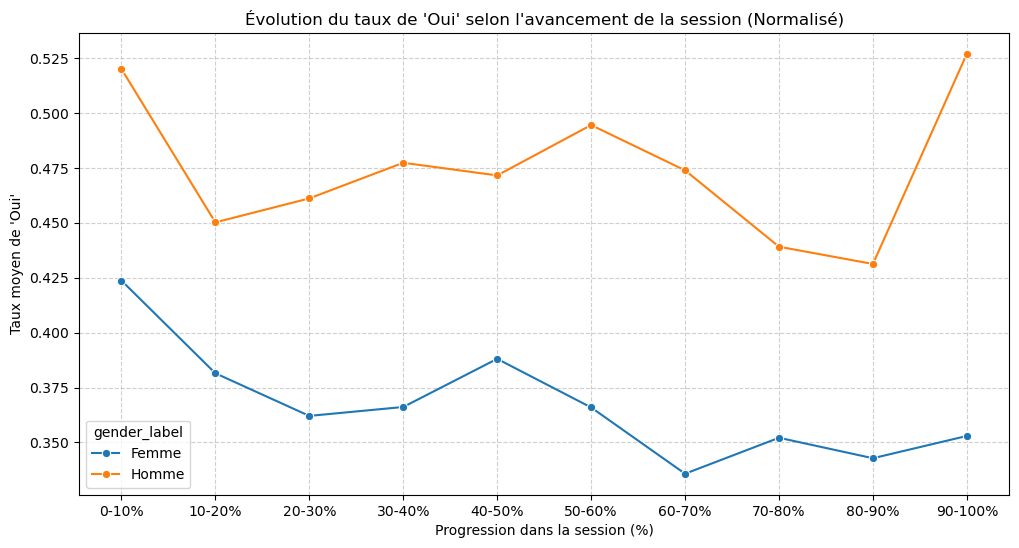

In [8]:
#ramené à une échelle de 0 à 100 RDV 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Préparation des données
df_q5 = df[['iid', 'gender', 'wave', 'round', 'order', 'dec']].copy()
df_q5['gender_label'] = df_q5['gender'].map({0: 'Femme', 1: 'Homme'})

# 2. Normalisation de la progression (0 à 1)
# 'order' est la position du RDV, 'round' est le nombre total de RDV dans la session
df_q5['pos_relative_this_wave'] = df_q5['order'] / df_q5['round']

# 3. Création de tranches de 10% (bins)
# On utilise pd.cut pour avoir des intervalles mathématiques fixes
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.1]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50-60%', '60-70%', '70-80%', '80-90%', '90-100%']

df_q5['bin_10'] = pd.cut(df_q5['pos_relative_this_wave'], 
                         bins=bins, 
                         labels=labels, 
                         include_lowest=True)

# 4. Calcul du taux de "oui" moyen par genre et par tranche de progression
evolution = df_q5.groupby(['gender_label', 'bin_10'], observed=True)['dec'].agg(
    taux_oui='mean'
).reset_index()

# 5. Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(data=evolution, x='bin_10', y='taux_oui', hue='gender_label', marker='o')
plt.title("Évolution du taux de 'Oui' selon l'avancement de la session (Normalisé)")
plt.xlabel("Progression dans la session (%)")
plt.ylabel("Taux moyen de 'Oui'")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [9]:
#sur une base de 21 RDV 
import plotly.express as px
# 5. ANALYSE DE L'EFFET D'ORDRE DES RENDEZ-VOUS SUR LE TAUX DE MATCH
# On calcule le taux de match moyen pour chaque position de rendez-vous
# 1. Calcul du taux de match par ordre
order_match = df.groupby('order')['match'].mean().reset_index()

# 2. CALCUL DE LA MOYENNE GLOBALE (tous rendez-vous confondus)
moyenne_globale = df['match'].mean()

# 3. Création du graphique
fig = px.line(
    order_match, 
    x='order', 
    y='match', 
    markers=True,
    title="Taux de Match selon l'ordre du rendez-vous",
    labels={
        'order': 'Position dans la soirée (1er, 2ème...)',
        'match': 'Probabilité de Match'
    },
    template="plotly_white"
)

# 4. AJOUT DE LA LIGNE DE MOYENNE
fig.add_hline(
    y=moyenne_globale, 
    line_dash="dash",          # Ligne en pointillés
    line_color="blue",         # Couleur différente pour bien la voir
    annotation_text=f"Moyenne globale: {moyenne_globale:.2f}",
    annotation_position="bottom right"
)

# Personnalisation de la courbe principale
fig.update_traces(line_color='red', marker=dict(size=10))

fig.show()

In [10]:
def calculer_ecart_stats(valeur_haute, valeur_basse):
    # 1. Calcul de l'écart brut (Points de pourcentage)
    points = valeur_haute - valeur_basse
    
    # 2. Calcul de l'augmentation relative (en %)
    # Formule : ((Vf - Vi) / Vi) * 100
    augmentation = (points / valeur_basse) * 100
    
    print(f"--- Analyse de l'écart ---")
    print(f"Écart brut : {points:.2f} points de pourcentage.")
    print(f"L'événement à {valeur_haute}% est {augmentation:.1f}% plus probable que celui à {valeur_basse}%.")
    print(f"Soit environ {valeur_haute/valeur_basse:.1f} fois plus de chances.")

# testons la fonction avec les valeurs de 21% et 7%
calculer_ecart_stats(23, 7)

--- Analyse de l'écart ---
Écart brut : 16.00 points de pourcentage.
L'événement à 23% est 228.6% plus probable que celui à 7%.
Soit environ 3.3 fois plus de chances.


L'Usure du Speed Dating (Diagramme de l'Effet d'Ordre)

On observe une légère baisse du taux de "Match" au fur et à mesure que la soirée avance. 

Le premier rendez-vous a environ 9% de chances de plus (23,0% vs 21,1%) d'aboutir à un match que le dernier. (et 230 % de plus que l'avant dernier ((0.23-.0.07)/0.07) * 100

Conclusion  : Il semble exister un "biais de sélection" lié à la fatigue.
Au début, les participants sont plus indulgents et enthousiastes. Après 15 ou 20 rencontres, ils deviennent plus sélectifs ou simplement plus fatigués, ce qui réduit les chances de "Oui" mutuel.

In [11]:
# --- ROBUSTESSE DE L'EFFET D'ORDRE : combien d'observations derrière chaque point ? ---
order_stats = df.groupby('order')['match'].agg(taux_match='mean', nb_observations='count').reset_index()

fig = px.bar(
    order_stats, x='order', y='nb_observations',
    title="Nombre d'observations par position dans la soirée",
    labels={'order': 'Position dans la soirée', 'nb_observations': "Nombre de rendez-vous"},
    template="plotly_white"
)
fig.show()

print(order_stats.to_string(index=False))


 order  taux_match  nb_observations
     1    0.230490              551
     2    0.159710              551
     3    0.165154              551
     4    0.179673              551
     5    0.176044              551
     6    0.162662              541
     7    0.153696              514
     8    0.155512              508
     9    0.201195              502
    10    0.177215              474
    11    0.163978              372
    12    0.123656              372
    13    0.153226              372
    14    0.145161              372
    15    0.131737              334
    16    0.134868              304
    17    0.114625              253
    18    0.158103              253
    19    0.185393              178
    20    0.180556              144
    21    0.069767               86
    22    0.227273               44


### ⚠️ Point de vigilance statistique sur l'effet d'ordre

Les dernières positions de la soirée reposent sur très peu d'observations : la position 21 n'a que 86 rendez-vous et la position 22 seulement 44, contre 500+ pour les premières positions. Le taux de 7% observé vers la fin (utilisé dans le calcul « 23% vs 7%, soit 3,3 fois plus de chances ») repose donc sur un échantillon trop petit pour être fiable — la marge d'erreur y est énorme.

**Conclusion plus robuste :** la comparaison ligne à ligne sur les positions 20+ est fragile, mais la tendance globale (visible sur la version normalisée en %, quelques cellules plus haut) — une érosion progressive du taux de "oui" au fil de la soirée — reste, elle, un résultat solide car elle agrège des centaines d'observations à chaque tranche.

In [12]:
# --- 7 HEATMAP : QUEL TRAIT PRÉDIT LE MIEUX LE DEUXIÈME RDV ? ---
# Calcul de la matrice de corrélation
cols_to_corr = ['dec', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar']
corr_matrix = df[cols_to_corr].corr()

# Création de la heatmap avec Plotly Express
fig = px.imshow(
    corr_matrix,
    text_auto='.2f',                # Affiche les valeurs avec 2 décimales (équivalent de fmt=".2f")
    aspect="auto",                  # Ajuste la taille des cases
    color_continuous_scale='RdBu_r', # Échelle de couleur divergente (équivalent de coolwarm)
    title="Corrélation entre les traits et la décision de revoir l'autre",
    labels=dict(color="Corrélation") # Légende de la barre de couleur
)

fig.show()

print("\n--- Analyse terminée ---")


--- Analyse terminée ---


 La hiérarchie réelle des traits (Heatmap de Corrélation)

Si l'on classe les traits par leur capacité réelle à provoquer un deuxième rendez-vous :Attractivité (0,49) : Le moteur principal, sans surprise

Humour (0,41) : Presque aussi important que le physique. C'est le facteur qui peut "sauver" un profil.

Intérêts communs (SHAR) (0,40) : Le partage d'activités est un pilier solide.

Sincérité (0,21) et Ambition ($0,20$) : Ce sont les "perdants" de l'expérience.

Conclusion  : Dans un format de 4 minutes, il est quasiment impossible de valoriser son ambition ou sa sincérité. Ce sont des qualités de "long terme" qui n'ont presque aucun impact sur l'instant vécu lors d'un speed dating.

## Conclusion générale : pourquoi les matchs baissent-ils ?

*Note de méthode : toutes les relations décrites ci-dessous sont des corrélations observées dans un contexte expérimental de speed dating encadré (2002-2004), pas des relations de cause à effet démontrées, et pas nécessairement transposables telles quelles au produit Tinder actuel.*

1. **Le physique domine, mais l'humour et les intérêts communs sont sous-estimés** — surtout par les femmes, qui déclarent l'intelligence comme priorité n°1 mais dont la décision réelle suit surtout l'attractivité et l'humour.
2. **L'origine raciale commune n'a aucun impact mesurable** sur l'envie de se revoir, contrairement aux intérêts communs qui comptent presque autant que l'humour.
3. **L'auto-évaluation ne prédit pas le succès** : se trouver séduisant(e) ne garantit rien sur la façon dont les autres nous perçoivent, pour les deux genres.
4. **La motivation s'érode pendant la session** : le taux de "oui" baisse progressivement au fil des rendez-vous, probablement par fatigue ou lassitude.

**Recommandation pour l'équipe marketing de Tinder :** encourager les profils à mettre en avant l'humour et des centres d'intérêt concrets plutôt que des traits abstraits (ambition, sincérité) que les utilisateurs ne valorisent pas en pratique ; et explorer des mécanismes qui limitent la fatigue de sélection (nombre de profils proposés par session, pauses) pour maintenir un taux de "oui" plus stable dans le temps.